In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas
import seaborn as sns

## Preprocessing

In [2]:
# Training image pre-processing
training_set = tf.keras.utils.image_dataset_from_directory(
    'dataset/train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 70295 files belonging to 38 classes.


In [3]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'dataset/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


## Building model

In [4]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from tensorflow.keras.models import Sequential

In [5]:
model = Sequential()

In [6]:
# Building convolution Layer
model.add(Conv2D(filters=32, kernel_size=3, padding='same', activation='relu', input_shape=[128,128,3]))
model.add(Conv2D(filters=32, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [7]:
model.add(Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=64, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [8]:
model.add(Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=128, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [9]:
model.add(Conv2D(filters=256, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=256, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [10]:
model.add(Conv2D(filters=512, kernel_size=3, padding='same', activation='relu'))
model.add(Conv2D(filters=512, kernel_size=3, activation='relu'))
model.add(MaxPool2D(pool_size=2, strides=2))

In [11]:
model.add(Dropout(0.25))

In [12]:
model.add(Flatten())

In [13]:
model.add(Dense(units=1500, activation='relu'))

In [14]:
model.add(Dropout(0.4))

In [15]:
#output layer
model.add(Dense(units=38, activation='softmax'))

In [16]:
# Compiling Model
model.compile(optimizer=tf.keras.optimizers.Adam(
    learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

## Training model

In [18]:
training_history = model.fit(x=training_set, validation_data=validation_set, epochs=10)

Epoch 1/10
2197/2197 [==============================] - 86s 34ms/step - loss: 1.3577 - accuracy: 0.6000 - val_loss: 0.4919 - val_accuracy: 0.8436
Epoch 2/10
2197/2197 [==============================] - 68s 31ms/step - loss: 0.4502 - accuracy: 0.8578 - val_loss: 0.2937 - val_accuracy: 0.9049
Epoch 3/10
2197/2197 [==============================] - 68s 31ms/step - loss: 0.2701 - accuracy: 0.9133 - val_loss: 0.1986 - val_accuracy: 0.9378
Epoch 4/10
2197/2197 [==============================] - 69s 31ms/step - loss: 0.1873 - accuracy: 0.9385 - val_loss: 0.1622 - val_accuracy: 0.9476
Epoch 5/10
2197/2197 [==============================] - 70s 32ms/step - loss: 0.1354 - accuracy: 0.9555 - val_loss: 0.1484 - val_accuracy: 0.9529
Epoch 6/10
2197/2197 [==============================] - 68s 31ms/step - loss: 0.1101 - accuracy: 0.9643 - val_loss: 0.1411 - val_accuracy: 0.9556
Epoch 7/10
2197/2197 [==============================] - 74s 34ms/step - loss: 0.0911 - accuracy: 0.9703 - val_loss: 0.1337 -

## Model Evaluation

In [19]:
# Model evaluation on training set
training_loss, training_accuracy = model.evaluate(training_set)

2197/2197 [==============================] - 33s 15ms/step - loss: 0.0204 - accuracy: 0.9938


In [20]:
print(training_loss, training_accuracy)

0.0203660000115633 0.993769109249115


In [21]:
# Model evaluation on validation set
training_loss, training_accuracy = model.evaluate(validation_set)

550/550 [==============================] - 8s 15ms/step - loss: 0.1143 - accuracy: 0.9666


In [22]:
print(training_loss, training_accuracy)

0.1142682135105133 0.9665945768356323


## Saving Model

In [23]:
model.save("model.keras")

In [24]:
training_history.history

{'loss': [1.3577332496643066,
  0.4502336382865906,
  0.2700674831867218,
  0.187276229262352,
  0.1354474127292633,
  0.11006657779216766,
  0.09113164991140366,
  0.077776700258255,
  0.07097094506025314,
  0.056729238480329514],
 'accuracy': [0.5999857783317566,
  0.8578134775161743,
  0.9132512807846069,
  0.9384735822677612,
  0.9555160403251648,
  0.964293360710144,
  0.9702966213226318,
  0.9755032658576965,
  0.9767835736274719,
  0.9819474816322327],
 'val_loss': [0.4918840527534485,
  0.29365938901901245,
  0.1985858529806137,
  0.16219517588615417,
  0.1483730673789978,
  0.14108580350875854,
  0.1337071806192398,
  0.12501539289951324,
  0.14094427227973938,
  0.11426830291748047],
 'val_accuracy': [0.8436148166656494,
  0.9049055576324463,
  0.937798798084259,
  0.9476439952850342,
  0.9528796076774597,
  0.9556112289428711,
  0.9572615623474121,
  0.9629524350166321,
  0.956407904624939,
  0.9665945768356323]}

In [25]:
#Recording history
import json
with open("training_history.json", "w") as f:
    json.dump(training_history.history, f)

### Accuracy Visualization

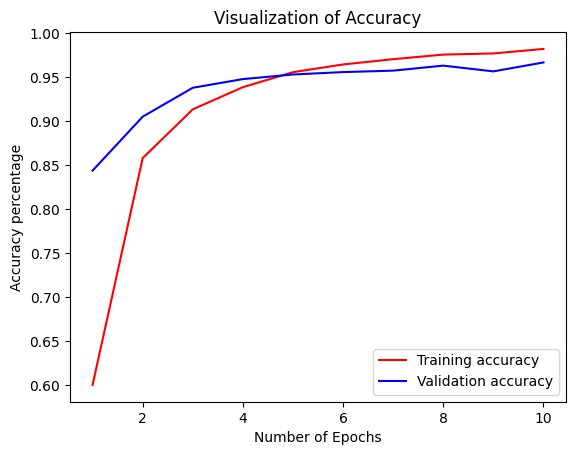

In [26]:
epochs = [i for i in range(1, 11)]
plt.plot(epochs, training_history.history['accuracy'], color='red', label='Training accuracy')
plt.plot(epochs, training_history.history['val_accuracy'], color='blue', label='Validation accuracy')
plt.xlabel("Number of Epochs")
plt.ylabel("Accuracy percentage")
plt.title("Visualization of Accuracy")
plt.legend()
plt.show()

### Some other metrics for model evaluation

In [27]:
class_name = validation_set.class_names

In [28]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'dataset/valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,
)

Found 17572 files belonging to 38 classes.


In [29]:
prediction = model.predict(test_set)

550/550 [==============================] - 7s 13ms/step


In [30]:
predicted_categories = tf.argmax(prediction, axis=1)

In [31]:
true_categories = tf.concat([y for x,y in test_set], axis=0)

In [32]:
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [33]:
y_true = tf.argmax(true_categories, axis=1)

In [35]:
from sklearn.metrics import classification_report, confusion_matrix

In [36]:
print(classification_report(y_true, predicted_categories, target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.98      0.92      0.95       504
                                 Apple___Black_rot       1.00      0.96      0.98       497
                          Apple___Cedar_apple_rust       0.98      0.99      0.98       440
                                   Apple___healthy       0.92      0.92      0.92       502
                               Blueberry___healthy       0.91      0.99      0.95       454
          Cherry_(including_sour)___Powdery_mildew       0.98      0.98      0.98       421
                 Cherry_(including_sour)___healthy       0.99      0.98      0.99       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.93      0.94      0.94       410
                       Corn_(maize)___Common_rust_       0.99      1.00      1.00       477
               Corn_(maize)___Northern_Leaf_Blight       0.95      0.96      0.

In [37]:
cn = confusion_matrix(y_true, predicted_categories)
cn

array([[465,   1,   0, ...,   0,   0,   0],
       [  2, 476,   0, ...,   0,   0,   0],
       [  0,   0, 435, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ..., 487,   0,   0],
       [  0,   0,   0, ...,   0, 445,   0],
       [  0,   0,   1, ...,   0,   0, 466]], dtype=int64)

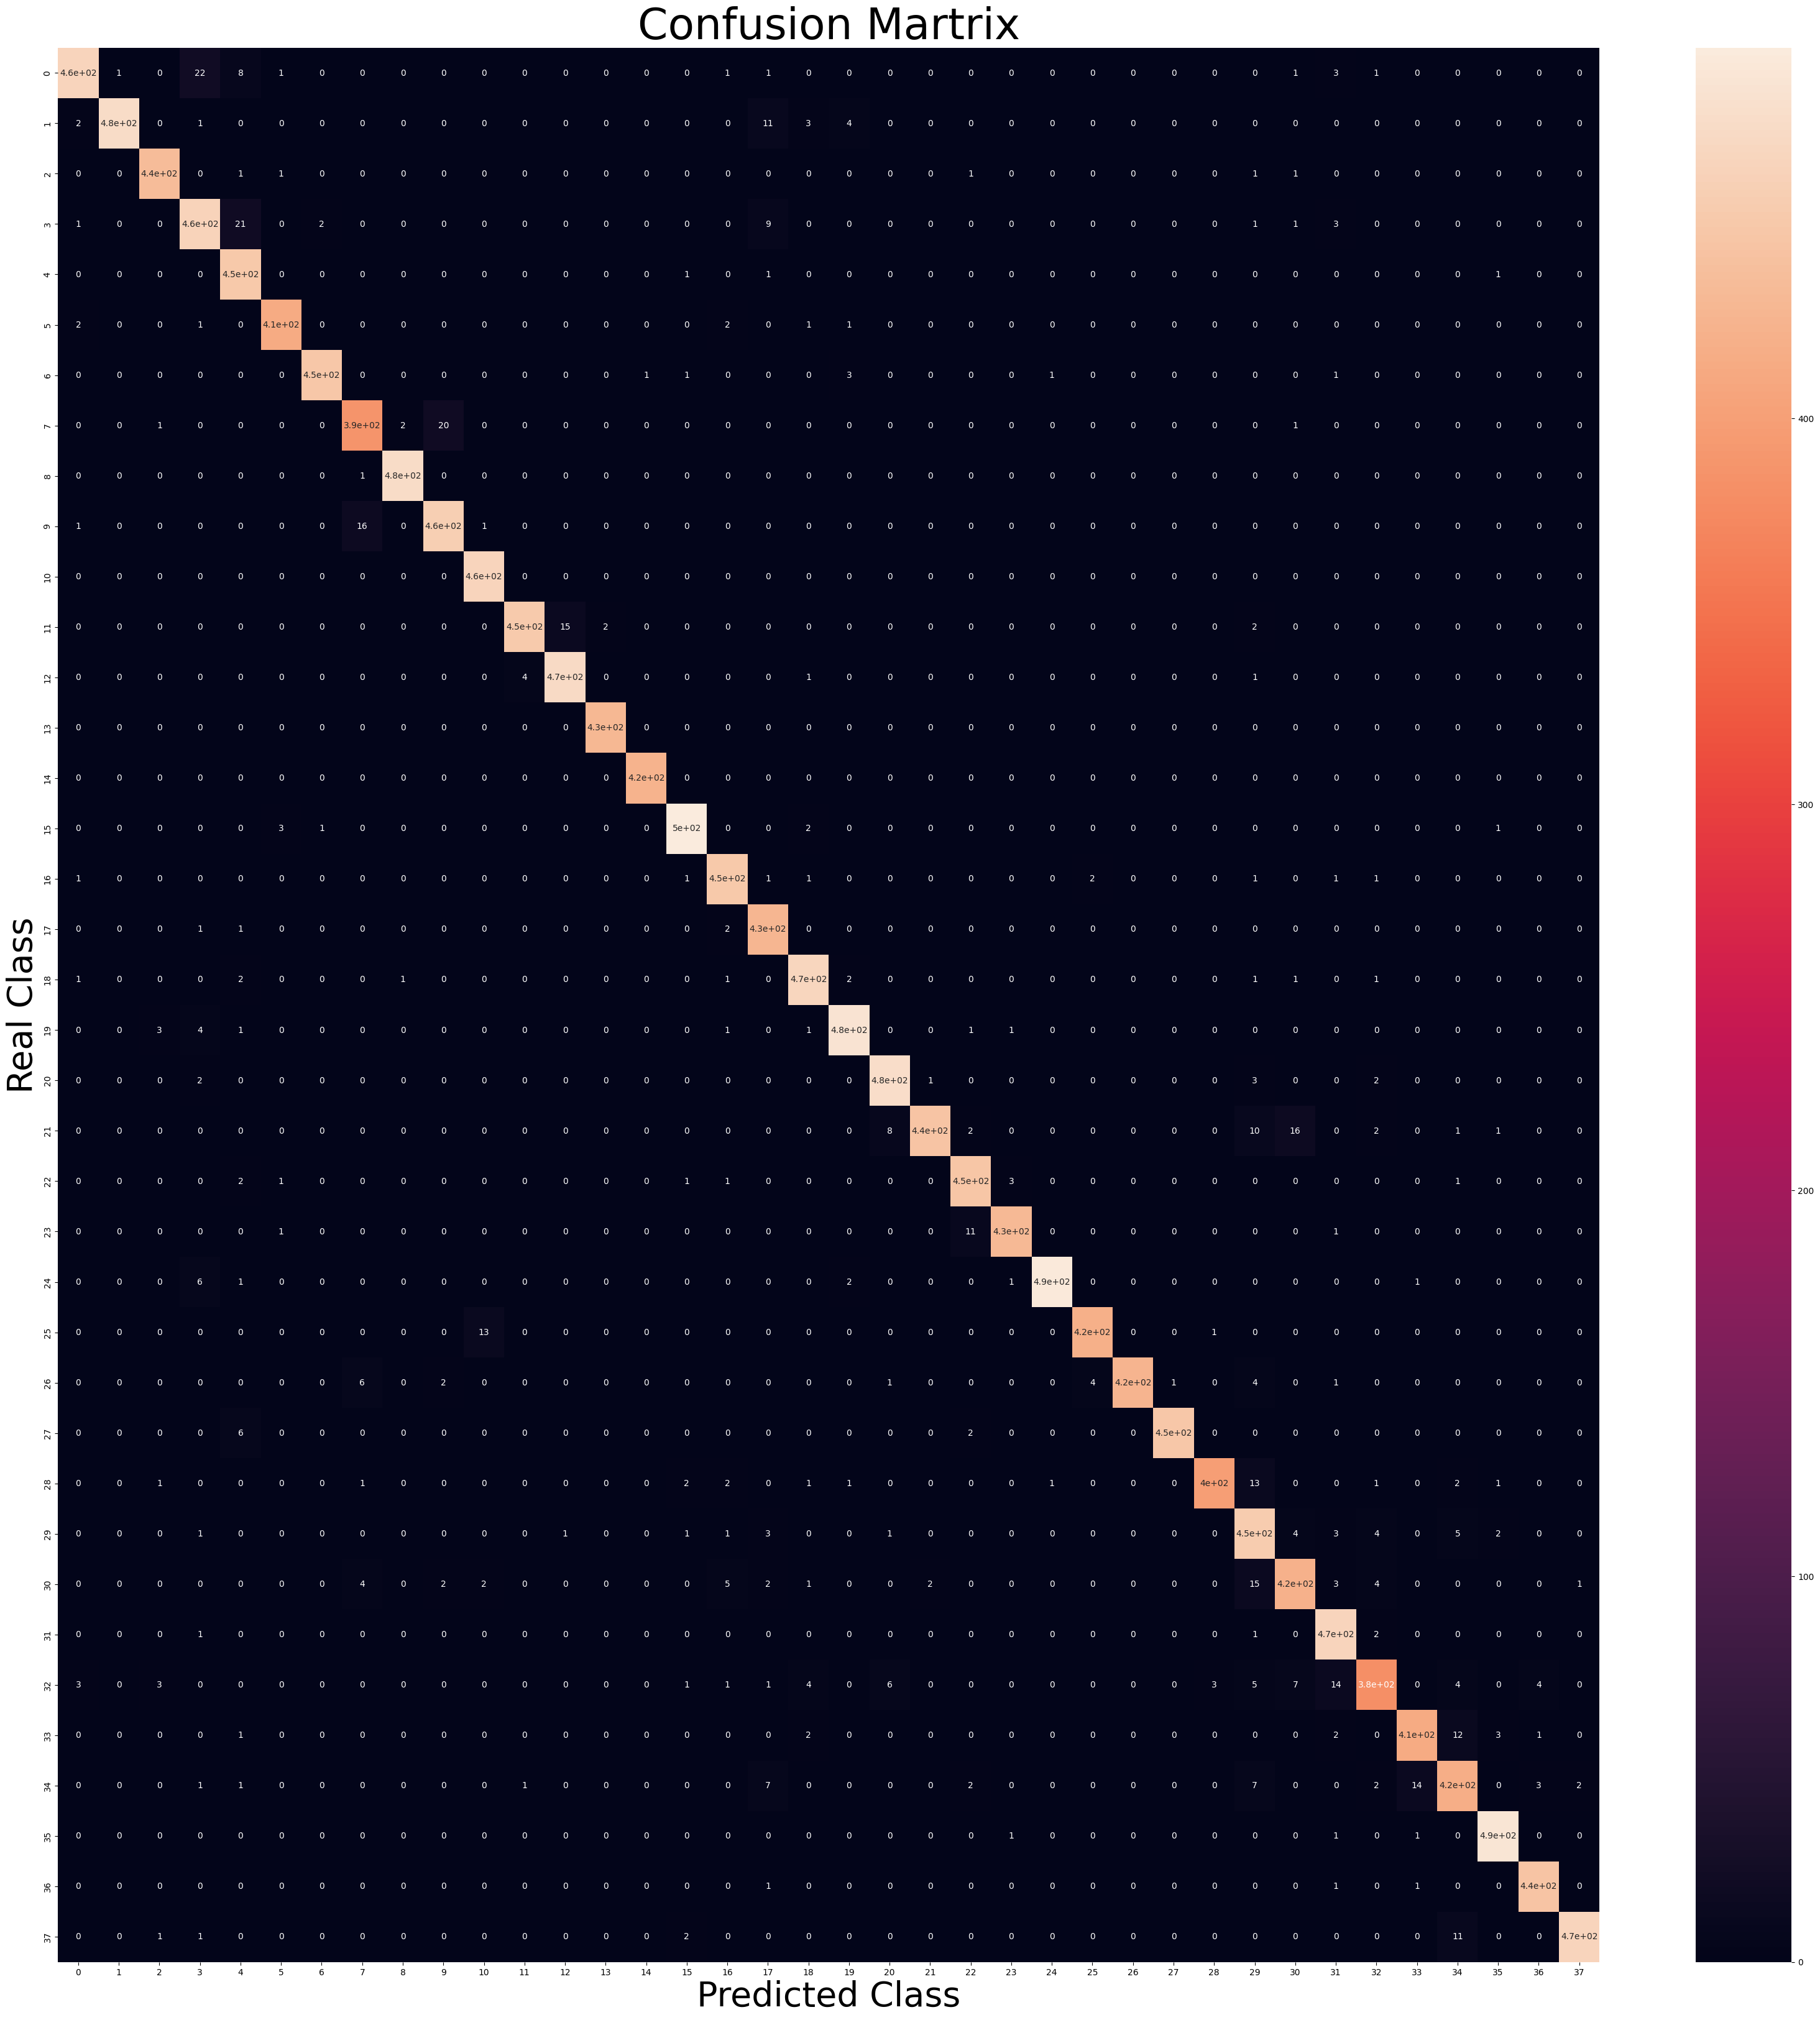

In [38]:
# Visualization
plt.figure(figsize=(40,40))
sns.heatmap(cn, annot=True, annot_kws={'size':10})
plt.xlabel("Predicted Class", fontsize=40)
plt.ylabel("Real Class", fontsize=40)
plt.title("Confusion Martrix", fontsize=50)
plt.show()